In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import openpyxl
import matplotlib.pyplot as plt

In [2]:
filepath_Luzern_weather_2025 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_recent.csv"
df_Luzern_weather_2025 = pd.read_csv(filepath_Luzern_weather_2025, sep=';')

filepath_Luzern_weather_until2024 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_historical.csv" 
df_Luzern_weather_until2024 = pd.read_csv(filepath_Luzern_weather_until2024, sep=';')

df_Luzern_weather = pd.concat([df_Luzern_weather_until2024, df_Luzern_weather_2025], axis=0, ignore_index=True)
display(df_Luzern_weather)

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,13.07.1880 00:00,17.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LUZ,14.07.1880 00:00,18.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LUZ,15.07.1880 00:00,20.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LUZ,16.07.1880 00:00,22.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LUZ,17.07.1880 00:00,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53102,LUZ,02.12.2025 00:00,2.3,5.5,0.1,1.6,8.4,-3.5,90.7,6.5,...,57.0,0.2,0.0,243.0,17.7,9.7,-0.2,NaN,NaN,NaN
53103,LUZ,03.12.2025 00:00,1.8,2.7,0.9,1.8,2.8,0.9,93.9,6.5,...,0.0,0.3,0.0,360.0,18.2,10.2,0.0,NaN,NaN,NaN
53104,LUZ,04.12.2025 00:00,2.2,3.9,0.8,1.9,5.7,-1.5,91.4,6.6,...,0.0,0.3,0.0,180.0,17.8,9.8,-0.1,NaN,NaN,NaN
53105,LUZ,05.12.2025 00:00,3.7,5.9,-0.1,2.7,6.3,-3.5,93.4,7.4,...,0.0,0.3,0.0,270.0,16.3,8.3,3.1,NaN,NaN,NaN


In [3]:
filepath_Luzern_weather_2025 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_recent.csv"
df_Luzern_weather_2025 = pd.read_csv(filepath_Luzern_weather_2025, sep=';')
display(df_Luzern_weather_2025)

filepath_Luzern_weather_until2024 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_historical.csv" 
df_Luzern_weather_until2024 = pd.read_csv(filepath_Luzern_weather_until2024, sep=';')
display(df_Luzern_weather_until2024)

df_Luzern_weather = pd.concat([df_Luzern_weather_until2024 , df_Luzern_weather_2025], axis=0, ignore_index=True)

# convert timestamp column to datetime
df_Luzern_weather["reference_timestamp"] = pd.to_datetime(
    df_Luzern_weather["reference_timestamp"], dayfirst=True)

# define date range
start_date = pd.Timestamp("2020-01-01")
end_date = pd.Timestamp(dt.datetime.today().date())

# filter
df_weather_filtered = df_Luzern_weather[(df_Luzern_weather["reference_timestamp"] >= start_date) & (df_Luzern_weather["reference_timestamp"] <= end_date)]

#select columns with relevant data
selected_columns_weather = ["reference_timestamp","rka150d0","rre150d0","sre000d0","tre200d0",]

df_weather_final = df_weather_filtered[selected_columns_weather]

df_weather_final

df_weather_final = df_weather_final.rename(columns={
    "reference_timestamp": "Datum", "rka150d0": "Niederschlag Tagessumme 0 UTC", "rre150d0": "Niederschlag Tagessumme 6 UTC", "sre000d0": "Sonnenscheindauer Tagessumme", "tre200d0": "Lufttemperatur 2m Tagesmittel"})

df_weather_final = df_weather_final.reset_index(drop=True)
df_weather_final

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,01.01.2025 00:00,-1.2,3.7,-3.5,-1.9,7.7,-6.3,91.6,5.1,...,68,0.1,0.0,217,21.2,13.2,-0.1,NaN,NaN,NaN
1,LUZ,02.01.2025 00:00,2.0,8.8,-2.7,0.6,6.7,-6.2,86.0,6.1,...,5,0.5,0.0,297,18.0,10.0,20.5,NaN,NaN,NaN
2,LUZ,03.01.2025 00:00,0.5,1.3,-1.0,-0.6,2.1,-4.6,89.0,5.6,...,1,0.3,0.0,354,19.5,11.5,0.3,NaN,NaN,NaN
3,LUZ,04.01.2025 00:00,-1.0,0.2,-2.3,-1.0,5.1,-3.9,80.3,4.6,...,14,0.2,0.0,329,21.0,13.0,3.3,NaN,NaN,NaN
4,LUZ,05.01.2025 00:00,2.9,7.7,0.0,1.9,12.4,-1.9,93.0,7.0,...,23,0.2,0.0,225,17.1,9.1,4.8,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,LUZ,02.12.2025 00:00,2.3,5.5,0.1,1.6,8.4,-3.5,90.7,6.5,...,57,0.2,0.0,243,17.7,9.7,-0.2,NaN,NaN,NaN
336,LUZ,03.12.2025 00:00,1.8,2.7,0.9,1.8,2.8,0.9,93.9,6.5,...,0,0.3,0.0,360,18.2,10.2,0.0,NaN,NaN,NaN
337,LUZ,04.12.2025 00:00,2.2,3.9,0.8,1.9,5.7,-1.5,91.4,6.6,...,0,0.3,0.0,180,17.8,9.8,-0.1,NaN,NaN,NaN
338,LUZ,05.12.2025 00:00,3.7,5.9,-0.1,2.7,6.3,-3.5,93.4,7.4,...,0,0.3,0.0,270,16.3,8.3,3.1,NaN,NaN,NaN


,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,13.07.1880 00:00,17.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LUZ,14.07.1880 00:00,18.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LUZ,15.07.1880 00:00,20.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LUZ,16.07.1880 00:00,22.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LUZ,17.07.1880 00:00,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52762,LUZ,27.12.2024 00:00,-1.1,-0.4,-2.1,-0.5,2.0,-1.7,91.8,5.2,...,0.0,0.3,0.0,315.0,21.1,13.1,0.0,NaN,NaN,NaN
52763,LUZ,28.12.2024 00:00,-1.4,0.0,-2.9,-0.8,1.8,-2.3,94.4,5.2,...,0.0,0.2,0.0,288.0,21.4,13.4,0.0,NaN,NaN,NaN
52764,LUZ,29.12.2024 00:00,-1.3,1.3,-2.8,-0.1,7.3,-2.1,93.2,5.2,...,41.0,0.1,0.0,270.0,21.3,13.3,-0.1,NaN,NaN,NaN
52765,LUZ,30.12.2024 00:00,-1.8,-0.2,-3.0,-1.0,0.9,-2.2,94.6,5.1,...,0.0,0.3,0.0,333.0,21.8,13.8,0.0,NaN,NaN,NaN


,Datum,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel
0,2020-01-01,0.0,0.0,0.0,0.0
1,2020-01-02,0.0,0.0,0.0,-0.5
2,2020-01-03,2.9,3.0,102.0,2.0
3,2020-01-04,0.1,0.0,13.0,5.1
4,2020-01-05,0.0,0.0,392.0,1.9
...,...,...,...,...,...
2162,2025-12-02,0.0,0.0,239.0,2.3
2163,2025-12-03,0.0,0.0,0.0,1.8
2164,2025-12-04,0.0,2.5,0.0,2.2
2165,2025-12-05,3.1,0.6,0.0,3.7


In [4]:

filepath_Births_Switzerland_100years = "data/px-x-0102020204_111.csv"
df_Births = pd.read_csv(filepath_Births_Switzerland_100years, sep=';', encoding='latin1')
display(df_Births)

# select only month columns (all except "Jahr")
month_cols = [c for c in df_Births.columns if c != "Jahr"]

# calculate average per month over all years
avg = df_Births[month_cols].mean()

# turn into a DataFrame and clean it up
avg_birthdays = avg.reset_index()
avg_birthdays.columns = ["month", "average number of births (100 year avg)"]

# optional: remove the German prefix from the month names
avg_birthdays["month"] = avg_birthdays["month"].str.replace("Lebendgeburten im ", "", regex=False)
avg_birthdays

,Jahr,Lebendgeburten im Januar,Lebendgeburten im Februar,Lebendgeburten im März,Lebendgeburten im April,Lebendgeburten im Mai,Lebendgeburten im Juni,Lebendgeburten im Juli,Lebendgeburten im August,Lebendgeburten im September,Lebendgeburten im Oktober,Lebendgeburten im November,Lebendgeburten im Dezember
0,1925,6004,6152,6766,6336,6477,6069,6122,6198,5716,5761,5365,5604
1,1926,5917,5833,6901,6271,6350,6096,6145,5925,5891,5597,5408,5784
2,1927,6190,5769,6481,6200,6256,5934,5973,5731,5281,4888,5080,5750
3,1928,5970,6145,6342,6038,6129,5787,5998,5693,5436,5397,5176,5483
4,1929,5810,5818,6382,5993,6258,5608,5860,5739,5548,5422,5173,5395
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2020,7108,6738,7071,7060,7369,7324,7810,7375,7440,7250,6494,6875
96,2021,7439,6876,7536,7269,7449,7428,7957,7831,7874,7842,7165,6978
97,2022,6933,6072,6679,6738,7064,7145,7428,7313,7115,6909,6422,6553
98,2023,6524,6059,6691,6424,7044,6994,7081,6901,6736,6823,6428,6319


,month,average number of births (100 year avg)
0,Januar,6852.12
1,Februar,6590.24
2,März,7288.88
3,April,7048.37
4,Mai,7211.93
5,Juni,6877.36
6,Juli,7076.14
7,August,6840.05
8,September,6763.88
9,Oktober,6589.36


In [5]:
filepath_Feiertage_Schweiz_2025 = "data/Feiertage_Schweiz_2025.csv"
df_public_holidays = pd.read_csv(filepath_Feiertage_Schweiz_2025, sep=',', encoding='latin1')

df_public_holidays.drop(columns=["Unnamed: 1"], inplace=True)
df_public_holidays.rename(columns={"2025" : "Datum", "Unnamed: 2" : "Feiertag"}, inplace=True)
display(df_public_holidays)

,Datum,Feiertag
0,01.01.2025,Neujahr
1,02.01.2025,Berchtoldstag
2,06.01.2025,Heilige Drei Könige (München und Stuttgart ges...
3,18.04.2025,Karfreitag
4,21.04.2025,Ostermontag
5,01.05.2025,Internationaler Tag der Arbeit
6,08.05.2025,80. Jahrestag der Befreiung vom Nationalsozial...
7,29.05.2025,Auffahrt
8,09.06.2025,Pfingstmontag
9,19.06.2025,"Fronleichnam (München, Frankfurt und Stuttgart..."


In [6]:
filepath_Feiertage_Ferien_LU_2024_25 = "data/fcal_Luzern_2024.csv"
df_public_holidays_LU = pd.read_csv(filepath_Feiertage_Ferien_LU_2024_25, sep=';')

df_public_holidays_LU['Bezeichnung'] = df_public_holidays_LU['Bezeichnung'].str.replace('�', 'ü')
df_public_holidays_LU["Datum"] = pd.to_datetime(df_public_holidays_LU["Datum"], dayfirst=True)
df_public_holidays_LU["Ende"] = pd.to_datetime(df_public_holidays_LU["Ende"], dayfirst=True)
df_public_holidays_LU = df_public_holidays_LU[df_public_holidays_LU["Datum"] <= pd.Timestamp(dt.datetime.today().date())]
df_public_holidays_LU.drop(columns=["Bemerkungen","Unnamed: 4"], inplace=True)

display(df_public_holidays_LU)

,Datum,Ende,Bezeichnung
0,2023-12-23,2024-01-07,Weihnachtsferien
1,2024-02-03,2024-02-18,Fasnachtsferien
2,2024-03-29,2024-04-14,Frühlingsferien
3,2024-05-09,2024-05-12,Auffahrtsferien
4,2024-05-20,2024-05-20,Pfingstmontag
5,2024-05-30,2024-06-02,Fronleichnam
6,2024-07-06,2024-08-18,Sommerferien
7,2024-09-28,2024-10-13,Herbstferien
8,2024-11-01,2024-11-01,Allerheiligen
9,2024-12-21,2025-01-05,Weihnachtsferien


,Tag,Restaurant,Terrasse,Datum
0,Fr,1620.2,0.0,2021-01-01
1,Sa,872.9,0.0,2021-01-02
2,So,0.0,0.0,2021-01-03
3,Mo,636.2,0.0,2021-01-04
4,Di,694.5,0.0,2021-01-05
...,...,...,...,...
1776,Mi,6279.9,362.6,2025-11-12
1777,Do,6735.1,307.4,2025-11-13
1778,Fr,12458.5,80.0,2025-11-14
1779,Sa,15362.0,1909.4,2025-11-15


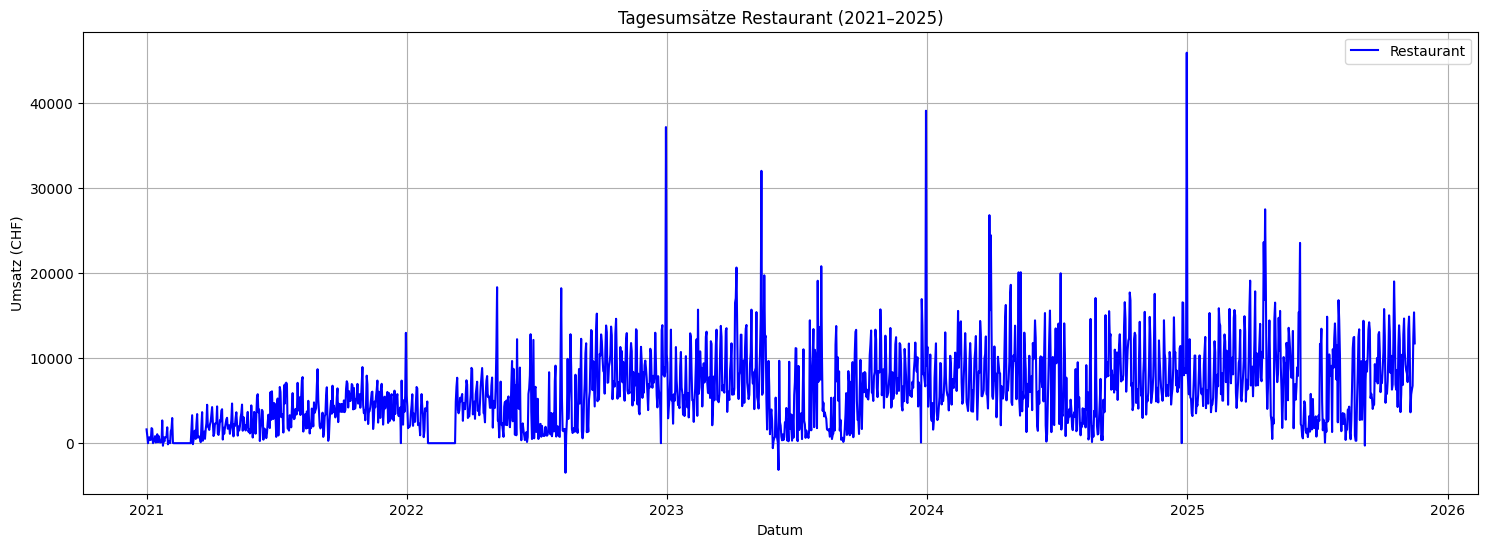

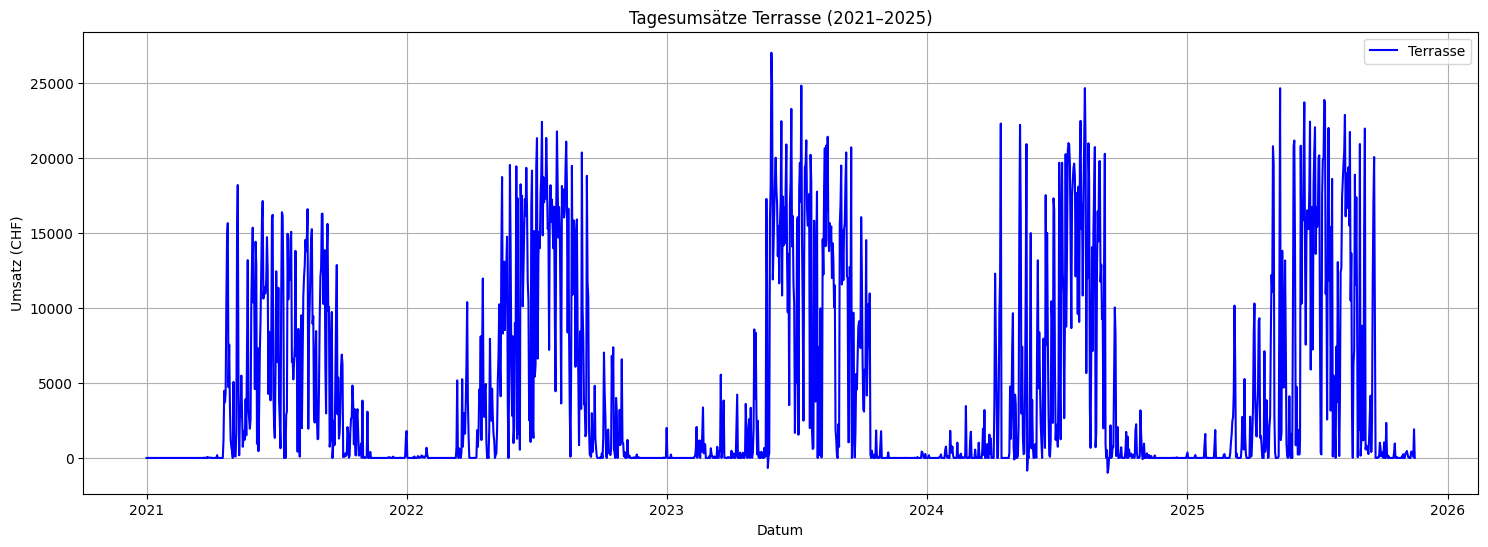

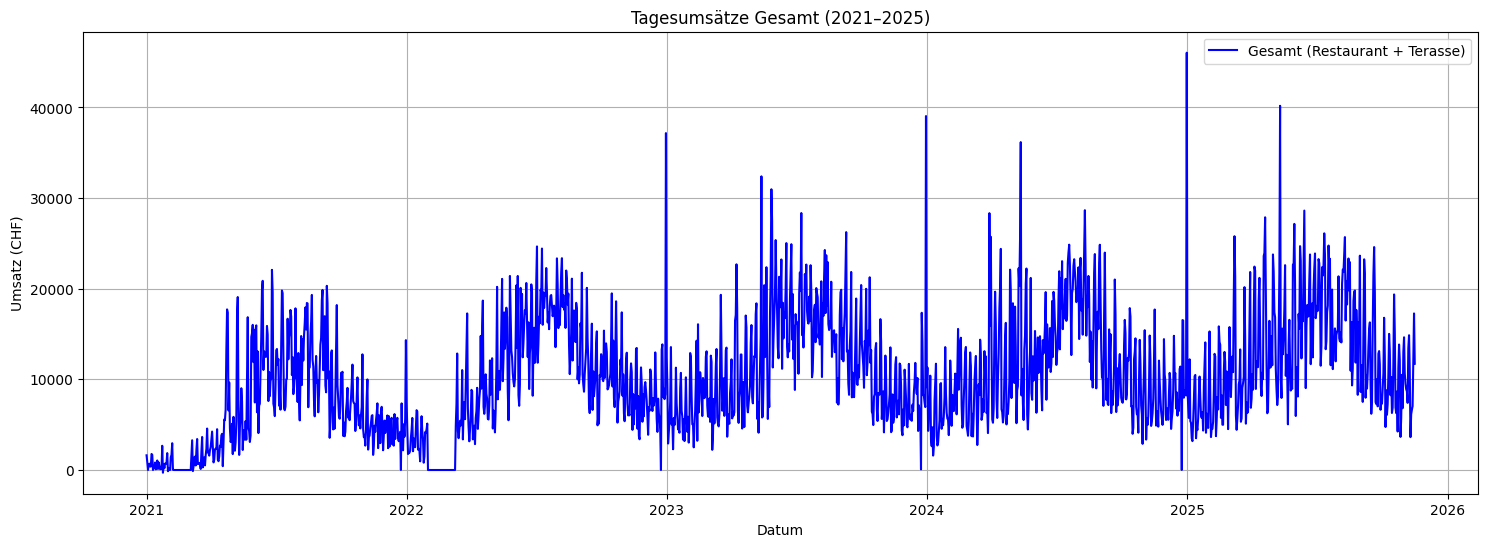

In [7]:
# Basis Pfad zur Excel-Datei
file_path_template = "data/SON Tagesumsätze {year}.xlsx"

# Jahre, die wir einlesen wollen
years = [2021, 2022, 2023, 2024, 2025]

# Mapping für Monat aus Sheetname
month_map = {
    '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6,
    '07': 7, '08': 8, '09': 9, '10': 10, '11': 11, '12': 12
}

# Liste für alle DataFrames
all_data = []

# Funktion zum Bereinigen und Konvertieren
def to_float(x):
    if pd.isna(x):
        return 0.0
    x = str(x).replace("’","").replace(",",".")
    return float(x)

# Echte Tageszeilen
tage = ['Mo','Di','Mi','Do','Fr','Sa','So', 'Mo.','Di.','Mi.','Do.','Fr.','Sa.','So.','DI'] # include all exceptions made in excel in regards to naming

for year in years:
    file_path = file_path_template.format(year=year)
    
    # Monatsnamen/Sheets für das Jahr
    sheets = [f"{str(i).zfill(2)}_{str(year)[-2:]}" for i in range(1,13)]
    
    for sheet in sheets:
        # Sheet einlesen, Header überspringen
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=2)
        
        # Relevante Spalten
        df = df[['Unnamed: 1', 'Restaurant', 'Terrasse']]
        df.columns = ['Tag', 'Restaurant', 'Terrasse']
        
        # Nur echte Tage
        df = df[df['Tag'].isin(tage)]
        
        # Jahr + Monat hinzufügen
        df['Jahr'] = year
        df['Monat'] = sheet
        
        # Restaurant/Terrasse konvertieren
        df['Restaurant'] = df['Restaurant'].apply(to_float)
        df['Terrasse'] = df['Terrasse'].apply(to_float)
        
        # Tag hochzählen
        month_id = sheet.split("_")[0]
        month_number = month_map[month_id]
        df['Datum'] = [pd.Timestamp(year=year, month=month_number, day=i+1) for i in range(len(df))]
        
        # Append
        all_data.append(df)

# Alles zusammenführen
final_df = pd.concat(all_data, ignore_index=True)

# Überflüssige Spalten löschen
final_df.drop(columns=['Jahr','Monat'], inplace=True)
final_df = final_df[final_df["Datum"] < pd.to_datetime("2025-11-17")]

# Ergebnis anzeigen
pd.set_option("display.max_rows",50)
display(final_df)


# Datum als Index setzen für einfaches Plotten
final_df_plots = final_df.sort_values('Datum')  # sicherstellen, dass die Daten chronologisch sind
final_df_plots.set_index('Datum', inplace=True)


# Restaurant Umsatz
plt.figure(figsize=(18,6))
plt.plot(final_df_plots.index, final_df_plots['Restaurant'], label='Restaurant', color='blue')
plt.title("Tagesumsätze Restaurant (2021–2025)")
plt.xlabel("Datum")
plt.ylabel("Umsatz (CHF)")
plt.legend()
plt.grid(True)
plt.show()

# Terrasse Umsatz
plt.figure(figsize=(18,6))
plt.plot(final_df_plots.index, final_df_plots['Terrasse'], label='Terrasse', color='blue')
plt.title("Tagesumsätze Terrasse (2021–2025)")
plt.xlabel("Datum")
plt.ylabel("Umsatz (CHF)")
plt.legend()
plt.grid(True)
plt.show()


# Terrasse Umsatz
plt.figure(figsize=(18,6))
plt.plot(final_df_plots.index, final_df_plots['Terrasse'] + final_df_plots['Restaurant'], label='Gesamt (Restaurant + Terasse)', color='blue')
plt.title("Tagesumsätze Gesamt (2021–2025)")
plt.xlabel("Datum")
plt.ylabel("Umsatz (CHF)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
start = "2021-01-01"
end   = "2025-11-16"
full_range = pd.date_range(start=start, end=end, freq="D")

# Convert DataFrame dates to a DatetimeIndex
df_dates = pd.to_datetime(final_df['Datum'])

# Identify missing dates
missing_dates = full_range.difference(df_dates)

# Create new DataFrame of missing dates
missing_df = pd.DataFrame({'missing_date': missing_dates})

display(missing_df)

for d in missing_dates:
    print(f"\nChecking date: {d.date()}")
    result = final_df[final_df["Datum"] == d]
    display(result)

,missing_date


In [9]:
filepath_GDP = "data/snb-data-gdpap-de-selection-20251121_0900.csv"
df_GDP = pd.read_csv(filepath_GDP, sep=";", header=2)
df_GDP = df_GDP[df_GDP["D0"] == "VVP"]
df_GDP.drop(columns=["D0","D1"],inplace=True)
display(df_GDP)

,Date,Value
1,2021-Q1,1.070853
3,2021-Q2,3.511144
5,2021-Q3,2.558028
7,2021-Q4,1.581198
9,2022-Q1,1.549760
11,2022-Q2,1.296646
13,2022-Q3,1.010062
15,2022-Q4,0.581978
17,2023-Q1,0.988351
19,2023-Q2,-0.428013


In [10]:
#Hinzufügen eines Wochenendbonus
final_df["is_fr_sa"] = final_df["Tag"].isin(["Fr", "Sa"]).astype(int)
final_df

,Tag,Restaurant,Terrasse,Datum,is_fr_sa
0,Fr,1620.2,0.0,2021-01-01,1
1,Sa,872.9,0.0,2021-01-02,1
2,So,0.0,0.0,2021-01-03,0
3,Mo,636.2,0.0,2021-01-04,0
4,Di,694.5,0.0,2021-01-05,0
...,...,...,...,...,...
1776,Mi,6279.9,362.6,2025-11-12,0
1777,Do,6735.1,307.4,2025-11-13,0
1778,Fr,12458.5,80.0,2025-11-14,1
1779,Sa,15362.0,1909.4,2025-11-15,1


# Merging

In [11]:
file_path_special_events = "data/Special_Events.xlsx"

sheets = ["2021", "2022", "2023", "2024", "2025"]

df_list = []
for sheet in sheets:
    df = pd.read_excel(
                file_path_special_events,
                sheet_name=sheet,
                usecols="A,I,L",   # A = Datum, I = Wert\
                header=None,
                skiprows=2)       # skip first two header rows\n",
    
    df.columns = ["Datum", "Ferien-Value", "Special-Day-Value"]

    df_list.append(df)
    
df_special_events = pd.concat(df_list, ignore_index=True)
df_special_events.fillna(0.0, inplace=True)
display(df_special_events)

,Datum,Ferien-Value,Special-Day-Value
0,2021-01-01,1.0,1.0
1,2021-01-02,1.0,0.0
2,2021-01-03,1.0,0.0
3,2021-01-04,1.0,0.0
4,2021-01-05,1.0,0.0
...,...,...,...
1760,2025-10-27,0.0,0.0
1761,2025-10-28,0.0,0.0
1762,2025-10-29,0.0,0.0
1763,2025-10-30,0.0,0.0


In [12]:
df_merged = pd.merge(final_df, df_special_events, on="Datum", how="left")
display(df_merged.head())

df_merged.to_csv("data/dataset-merged.csv", index=False)

,Tag,Restaurant,Terrasse,Datum,is_fr_sa,Ferien-Value,Special-Day-Value
0,Fr,1620.2,0.0,2021-01-01,1,1.0,1.0
1,Sa,872.9,0.0,2021-01-02,1,1.0,0.0
2,So,0.0,0.0,2021-01-03,0,1.0,0.0
3,Mo,636.2,0.0,2021-01-04,0,1.0,0.0
4,Di,694.5,0.0,2021-01-05,0,1.0,0.0


In [13]:
display(avg_birthdays)

df_merged_1 = pd.merge(df_merged, df_weather_final, on="Datum", how="left")



,month,average number of births (100 year avg)
0,Januar,6852.12
1,Februar,6590.24
2,März,7288.88
3,April,7048.37
4,Mai,7211.93
5,Juni,6877.36
6,Juli,7076.14
7,August,6840.05
8,September,6763.88
9,Oktober,6589.36


In [14]:
df_merged_1['month'] = df_merged_1['Datum'].dt.month_name(locale='de_DE')
df_merged_1.head()

,Tag,Restaurant,Terrasse,Datum,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,month
0,Fr,1620.2,0.0,2021-01-01,1,1.0,1.0,0.6,0.6,0.0,1.7,Januar
1,Sa,872.9,0.0,2021-01-02,1,1.0,0.0,0.0,0.0,0.0,1.5,Januar
2,So,0.0,0.0,2021-01-03,0,1.0,0.0,0.0,0.0,0.0,0.5,Januar
3,Mo,636.2,0.0,2021-01-04,0,1.0,0.0,0.0,0.0,0.0,0.1,Januar
4,Di,694.5,0.0,2021-01-05,0,1.0,0.0,0.0,0.0,0.0,-0.2,Januar


In [15]:
df_merged_2 = pd.merge(df_merged_1, avg_birthdays, on="month", how="left")

In [16]:
df_merged_2 = df_merged_2.rename(columns={"month": "Monat", 
                                          "average number of births (100 year avg)": "Durchschnittliche Anzahl Geburtstage (über 100 Jahre)"
                                          })

df_merged_2# Liste aller Spalten holen
cols = list(df_merged_2.columns)

# "Monat" direkt hinter "Datum" schieben
cols.insert(cols.index("Datum") + 1, cols.pop(cols.index("Monat")))

# DataFrame neu anordnen
df_merged_2 = df_merged_2[cols]


display(df_merged_2)

df_merged_2.to_csv("data/dataset-merged-2.csv", index=False)

,Tag,Restaurant,Terrasse,Datum,Monat,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre)
0,Fr,1620.2,0.0,2021-01-01,Januar,1,1.0,1.0,0.6,0.6,0.0,1.7,6852.12
1,Sa,872.9,0.0,2021-01-02,Januar,1,1.0,0.0,0.0,0.0,0.0,1.5,6852.12
2,So,0.0,0.0,2021-01-03,Januar,0,1.0,0.0,0.0,0.0,0.0,0.5,6852.12
3,Mo,636.2,0.0,2021-01-04,Januar,0,1.0,0.0,0.0,0.0,0.0,0.1,6852.12
4,Di,694.5,0.0,2021-01-05,Januar,0,1.0,0.0,0.0,0.0,0.0,-0.2,6852.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,Mi,6279.9,362.6,2025-11-12,November,0,NaN,NaN,0.0,0.0,419.0,6.2,6225.59
1777,Do,6735.1,307.4,2025-11-13,November,0,NaN,NaN,0.0,0.0,426.0,8.1,6225.59
1778,Fr,12458.5,80.0,2025-11-14,November,1,NaN,NaN,0.0,0.0,113.0,9.2,6225.59
1779,Sa,15362.0,1909.4,2025-11-15,November,1,NaN,NaN,0.0,0.0,396.0,12.0,6225.59


Cleaning

In [17]:
df_merged_2.isna().sum()

Tag                                                       0
Restaurant                                                0
Terrasse                                                  0
Datum                                                     0
Monat                                                     0
is_fr_sa                                                  0
Ferien-Value                                             16
Special-Day-Value                                        16
Niederschlag Tagessumme 0 UTC                             3
Niederschlag Tagessumme 6 UTC                             0
Sonnenscheindauer Tagessumme                              0
Lufttemperatur 2m Tagesmittel                             0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)     0
dtype: int64

In [18]:
#Werte NaN bei Special-Day-Values und Ferien_Value auffüllen mit 0
df_merged_2["Ferien-Value"] = df_merged_2["Ferien-Value"].fillna(0)
df_merged_2["Special-Day-Value"] = df_merged_2["Special-Day-Value"].fillna(0)

#Niederschlag Tagessumme 0 UTC löschen
df_merged_2 = df_merged_2.drop(columns=["Niederschlag Tagessumme 0 UTC"])

In [19]:
df_merged_2.isna().sum()

Tag                                                      0
Restaurant                                               0
Terrasse                                                 0
Datum                                                    0
Monat                                                    0
is_fr_sa                                                 0
Ferien-Value                                             0
Special-Day-Value                                        0
Niederschlag Tagessumme 6 UTC                            0
Sonnenscheindauer Tagessumme                             0
Lufttemperatur 2m Tagesmittel                            0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)    0
dtype: int64

In [20]:
#negative Umsätze rausnehmen. Wir haben jeweils den Durchschnitt desselben Wochentages über die letzten vier Wochen genommen. Ausser sie sind nicht verfügbar (Anfang des Datasets). Dann haben wir stattdessen den Vortag genommen.
import pandas as pd

# Datum als Datetime
df_merged_2["Datum"] = pd.to_datetime(df_merged_2["Datum"])

col_umsatz = "Restaurant"

# nach Datum sortieren
df_merged_2 = df_merged_2.sort_values("Datum").reset_index(drop=True)

# Maske für negative Umsätze
neg_mask = df_merged_2[col_umsatz] < 0

print("Anzahl negativer Umsätze vorher:", neg_mask.sum())

for idx in df_merged_2[neg_mask].index:
    current_date = df_merged_2.at[idx, "Datum"]
    weekday = current_date.weekday()              # 0=Mo, ..., 6=So
    start_date = current_date - pd.Timedelta(weeks=4)

    # gleiche Wochentage der letzten 4 Wochen, nur positive Umsätze
    hist = df_merged_2[
        (df_merged_2["Datum"] < current_date) &
        (df_merged_2["Datum"] >= start_date) &
        (df_merged_2["Datum"].dt.weekday == weekday) &
        (df_merged_2[col_umsatz] >= 0)
    ]

    # Fallback 1: gleicher Wochentag über gesamte Vergangenheit
    if hist.empty:
        hist = df_merged_2[
            (df_merged_2["Datum"] < current_date) &
            (df_merged_2["Datum"].dt.weekday == weekday) &
            (df_merged_2[col_umsatz] >= 0)
        ]

    # Fallback 2: globaler Mittelwert aller nicht-negativen Umsätze
    if hist.empty:
        replacement = df_merged_2.loc[df_merged_2[col_umsatz] >= 0, col_umsatz].mean()
    else:
        replacement = hist[col_umsatz].mean()

    df_merged_2.at[idx, col_umsatz] = replacement

# Kontrolle
print("Anzahl negativer Umsätze nachher:", (df_merged_2[col_umsatz] < 0).sum())


Anzahl negativer Umsätze vorher: 7
Anzahl negativer Umsätze nachher: 0


In [21]:
df_merged_2["Tagesumsatz Restaurant"] = (
    df_merged_2["Restaurant"].fillna(0) +
    df_merged_2["Terrasse"].fillna(0)
)
df_merged_2.head()

,Tag,Restaurant,Terrasse,Datum,Monat,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre),Tagesumsatz Restaurant
0,Fr,1620.2,0.0,2021-01-01,Januar,1,1.0,1.0,0.6,0.0,1.7,6852.12,1620.2
1,Sa,872.9,0.0,2021-01-02,Januar,1,1.0,0.0,0.0,0.0,1.5,6852.12,872.9
2,So,0.0,0.0,2021-01-03,Januar,0,1.0,0.0,0.0,0.0,0.5,6852.12,0.0
3,Mo,636.2,0.0,2021-01-04,Januar,0,1.0,0.0,0.0,0.0,0.1,6852.12,636.2
4,Di,694.5,0.0,2021-01-05,Januar,0,1.0,0.0,0.0,0.0,-0.2,6852.12,694.5


In [22]:
# Trim the mother's day exception to upper tukey fence
col = "Tagesumsatz Restaurant"

Q1 = df_merged_2[col].quantile(0.25)
Q3 = df_merged_2[col].quantile(0.75)
IQR = Q3 - Q1

upper_tukey_fence = Q3 + 1.5 * IQR
print(upper_tukey_fence)
display(df_merged_2[df_merged_2[col] > upper_tukey_fence])


28342.100000000002


,Tag,Restaurant,Terrasse,Datum,Monat,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre),Tagesumsatz Restaurant
729,Sa,37123.7,40.50,2022-12-31,Dezember,1,1.000000,1.00,0.0,172.0,8.2,6455.11,37164.20
863,So,31984.7,409.60,2023-05-14,Mai,0,0.142857,1.00,18.4,23.0,11.2,7211.93,32394.30
877,So,3959.1,27010.30,2023-05-28,Mai,0,0.000000,1.00,0.0,815.0,18.4,7211.93,30969.40
919,So,3533.6,24814.95,2023-07-09,Juli,0,0.857143,0.00,0.0,670.0,25.6,7076.14,28348.55
1094,So,39045.0,0.00,2023-12-31,Dezember,0,1.000000,1.00,2.9,50.0,3.0,6455.11,39045.00
1227,So,20072.1,16098.10,2024-05-12,Mai,0,0.142857,1.00,0.3,401.0,17.1,7211.93,36170.20
1317,Sa,4009.5,24650.22,2024-08-10,August,1,1.000000,0.00,0.0,801.0,23.5,6840.05,28659.72
1460,Di,45857.5,174.70,2024-12-31,Dezember,0,1.000000,1.00,0.0,175.0,-1.9,6455.11,46032.20
1591,So,15532.1,24644.00,2025-05-11,Mai,0,0.142857,1.00,0.0,800.0,15.8,7211.93,40176.10
1625,Sa,4915.8,23701.90,2025-06-14,Juni,1,0.000000,0.75,0.0,741.0,24.7,6877.36,28617.70


We can see, that outliers occur on:
* New Year's Eve
* Mother's Day
* Pfingtsonntag
* Some random days: 9.7.2023, 10.8.2024, 14.6.2025. We can neglect those

In [23]:
df_merged_2.to_csv("data/dataset-merged-2.csv", index=False)

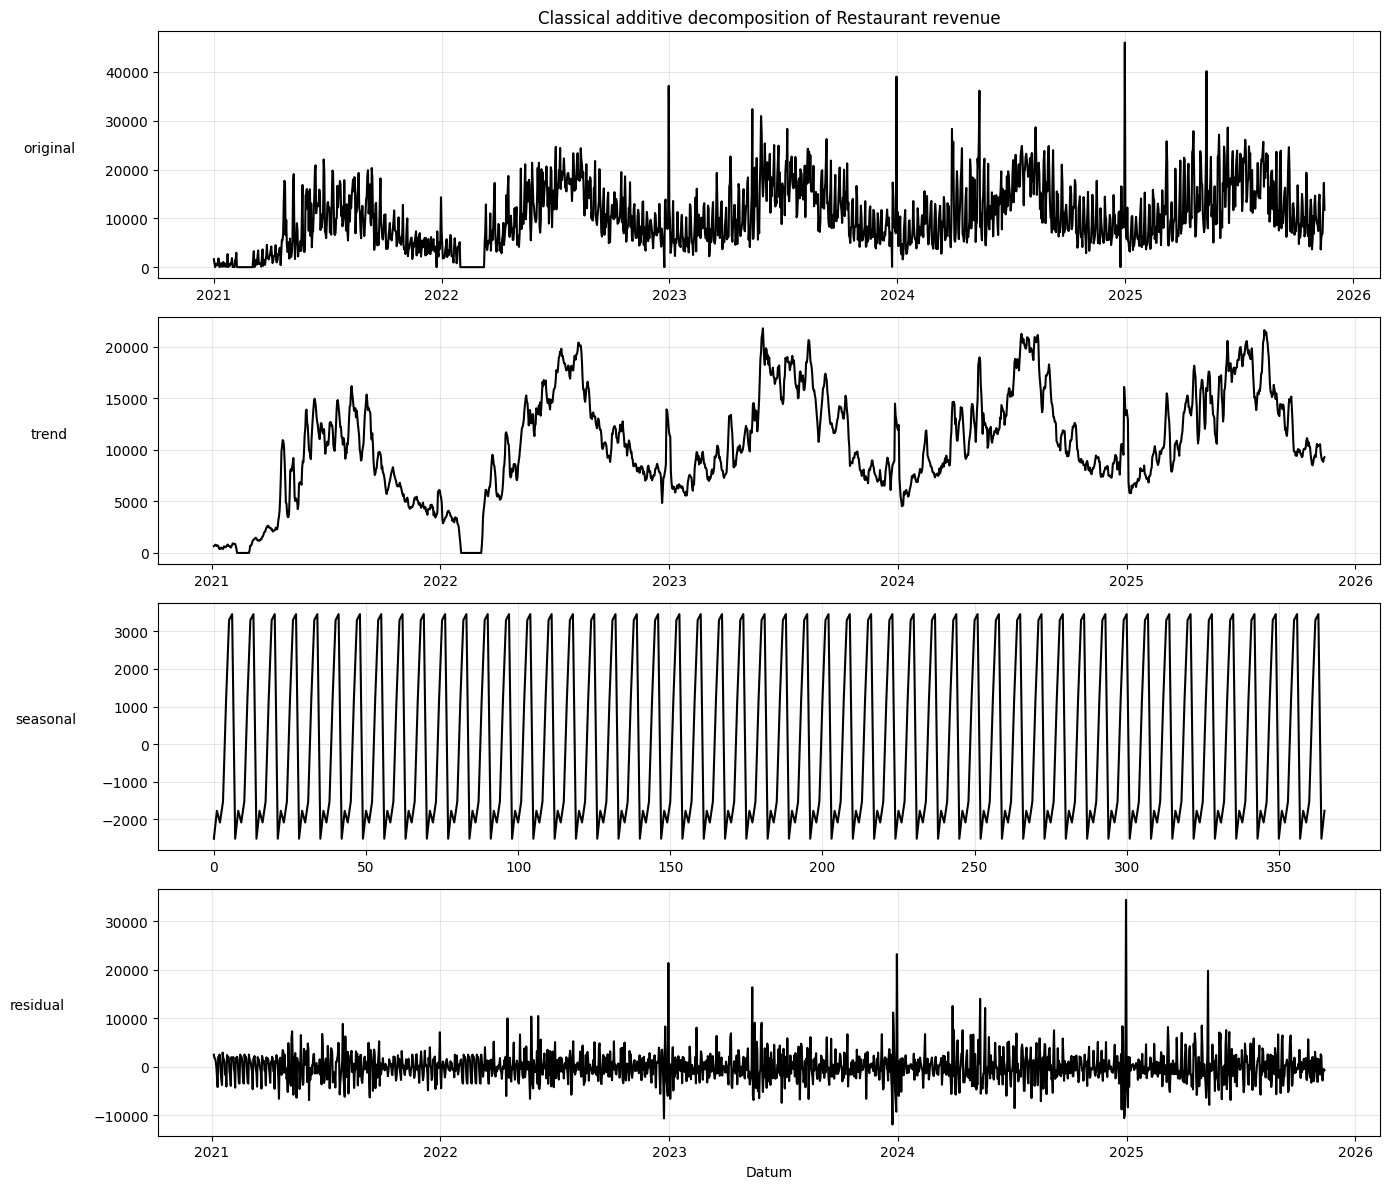

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# 1) Load and prepare the data
# -----------------------------
df = pd.read_csv("data/dataset-merged-2.csv")

df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum").set_index("Datum")
df = df.asfreq("D")  # fill missing dates (NaN)

y = df["Tagesumsatz Restaurant"]

# -----------------------------
# 2) Classical decomposition
# -----------------------------
result = seasonal_decompose(
    y,
    model="additive",   # or "multiplicative"
    period=7            # weekly pattern
)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

seasonal_2024 = seasonal["2024"]


fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# ---- ORIGINAL ----
axes[0].plot(y.index, y.values, color="black")
axes[0].set_ylabel("original", rotation=0, labelpad=40)
axes[0].set_title("Classical additive decomposition of Restaurant revenue")
axes[0].grid(True, alpha=0.3)

# ---- TREND ----
axes[1].plot(trend.index, trend.values, color="black")
axes[1].set_ylabel("trend", rotation=0, labelpad=40)
axes[1].grid(True, alpha=0.3)

# ---- SEASONAL  ----

# ---- SEASONAL PANEL (axes[2]) ----

# extract seasonal component for 2024 and drop NaNs
seasonal_2024 = result.seasonal.loc["2024"].dropna()

# numeric x-axis: 0, 1, 2, 3, ..., len-1
x = list(range(len(seasonal_2024)))

axes[2].plot(x, seasonal_2024.values, color="black")

axes[2].set_ylabel("seasonal", rotation=0, labelpad=40)
axes[2].grid(True, alpha=0.3)

# Force numeric x-axis — completely disable date formatting
import matplotlib.ticker as mticker
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
axes[2].xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))


# ---- RESIDUAL ----
axes[3].plot(resid.index, resid.values, color="black")
axes[3].set_ylabel("residual", rotation=0, labelpad=40)
axes[3].set_xlabel("Datum")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


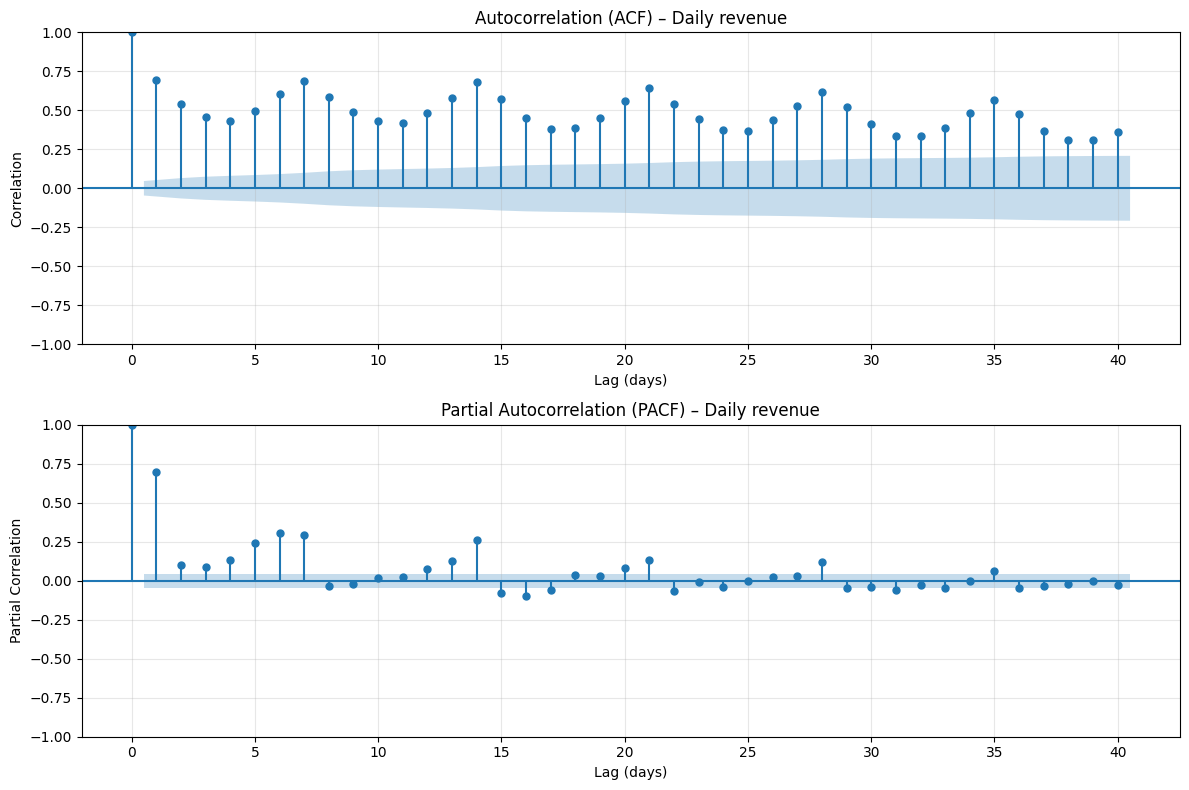

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -----------------------------
# 1) Load and prepare the data
# -----------------------------
df = pd.read_csv("data/dataset-merged-2.csv")

df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum").set_index("Datum")
df = df.asfreq("D")  # ensure daily frequency

y = df["Tagesumsatz Restaurant"].fillna(0)

# -----------------------------
# 2) Plot ACF + PACF
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ---- ACF ----
plot_acf(y, ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation (ACF) – Daily revenue")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Correlation")
axes[0].grid(True, alpha=0.3)

# ---- PACF ----
plot_pacf(y, ax=axes[1], lags=40, method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF) – Daily revenue")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial Correlation")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



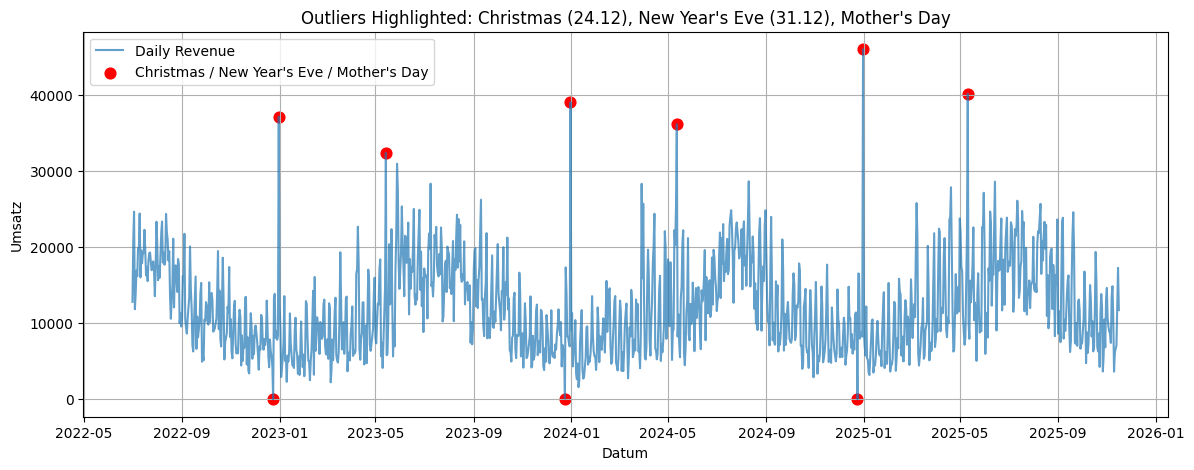

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 1) Load & prepare data
# =============================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Set Datum as index
df = df.set_index("Datum")

# Filter using index (correct)
df = df[df.index >= "2022-07-01"]


y = df["Tagesumsatz Restaurant"]

# =============================
# 2) Helper: find Mother's Day for each year
#    Mother's Day = second Sunday of May
# =============================
def mothers_day(year):
    may = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="D")
    sundays = may[may.weekday == 6]   # Sunday = 6
    return sundays[1]                 # second Sunday

mothers_days = [mothers_day(y) for y in df.index.year.unique()]

# =============================
# 3) Create masks for special days
# =============================
christmas_mask = (df.index.month == 12) & (df.index.day == 24)
silvester_mask = (df.index.month == 12) & (df.index.day == 31)
mothersday_mask = df.index.isin(mothers_days)

# Combine into one mask
special_mask = christmas_mask | silvester_mask | mothersday_mask

# =============================
# 4) Plot
# =============================
plt.figure(figsize=(14,5))
plt.plot(y.index, y.values, label="Daily Revenue", alpha=0.7)

# Highlight special days
plt.scatter(y.index[special_mask],
            y[special_mask],
            color="red",
            s=60,
            label="Christmas / New Year's Eve / Mother's Day")

plt.title("Outliers Highlighted: Christmas (24.12), New Year's Eve (31.12), Mother's Day")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.grid(True)
plt.legend()
plt.show()